In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import ternary
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
from Functions_sirbu_loreto import *
from scipy.spatial.distance import pdist, squareform

# ANDAMENTO ENTROPIA - OVERLAP 

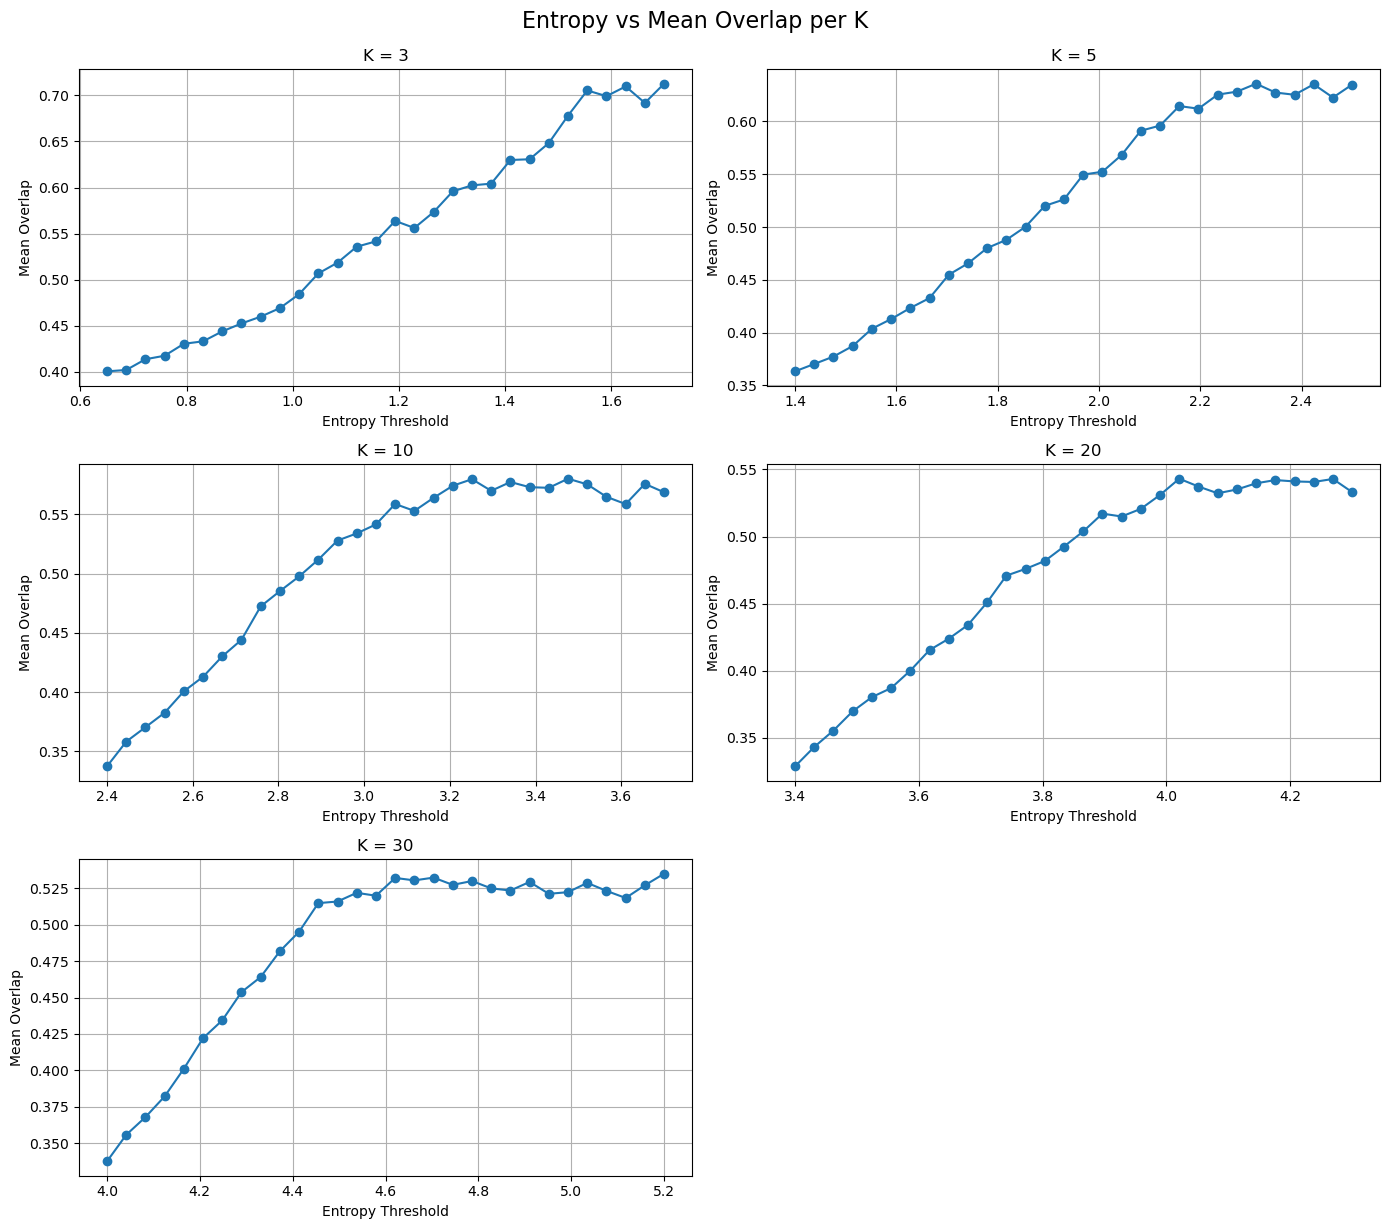

In [2]:


entropy_values = []
overlap_values = []
runs_dict = {}
num_run = 3
N = 100
n_points = 30  # Assicurati che sia definito

entropy_ranges = {
    3: np.linspace(0.65, 1.7, n_points),
    5: np.linspace(1.4, 2.5, n_points),
    10: np.linspace(2.4, 3.7, n_points),
    20: np.linspace(3.4, 4.3, n_points),
    30: np.linspace(4.0, 5.2, n_points),
}

fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

for idx, (K, entropies) in enumerate(entropy_ranges.items()): 
    runs_dict = {}
    for i in range(num_run):
        runs_dict[i] = {}
        entropy_values = []
        overlap_values = []
        runs_dict[i]['entropy'] =  []
        runs_dict[i]['overlap'] = []

        for entropy_threshold in entropies:
            pop = generate_population(K, N, entropy_threshold)
            entropy_values.append(entropy_threshold)
            overlap = calculate_total_overlap(pop)
            overlap_values.append(overlap)

        runs_dict[i]['entropy'] = entropy_values
        runs_dict[i]['overlap'] = overlap_values

    num_thresholds = len(runs_dict[0]['overlap'])
    mean_overlaps = []
    entropy_values = runs_dict[0]['entropy']

    for j in range(num_thresholds):
        overlaps_at_j = [runs_dict[i]['overlap'][j] for i in range(num_run)]
        mean_overlaps.append(np.mean(overlaps_at_j))

    axs[idx].plot(entropy_values, mean_overlaps, marker='o', linestyle='-')
    axs[idx].set_title(f'K = {K}')
    axs[idx].set_xlabel('Entropy Threshold')
    axs[idx].set_ylabel('Mean Overlap')
    axs[idx].grid(True)

# Se ci sono meno di 6 subplot, nascondi quelli vuoti
for i in range(len(entropy_ranges), len(axs)):
    axs[i].axis('off')

plt.tight_layout()
plt.suptitle('Entropy vs Mean Overlap per K', fontsize=16, y=1.02)
plt.show()


# LET'S VERIFY PAPER VALUE FOR K=3 overlap-entropy

Popolazione nel simplesso con Initial Overlap = 0.56 S_trashold = 1.20
Popolazione nel simplesso con Initial Overlap = 0.66 S_trashold = 1.50


/Users/alicenappa/miniconda3/lib/python3.13/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


Popolazione nel simplesso con Initial Overlap = 0.68 S_trashold = 1.60


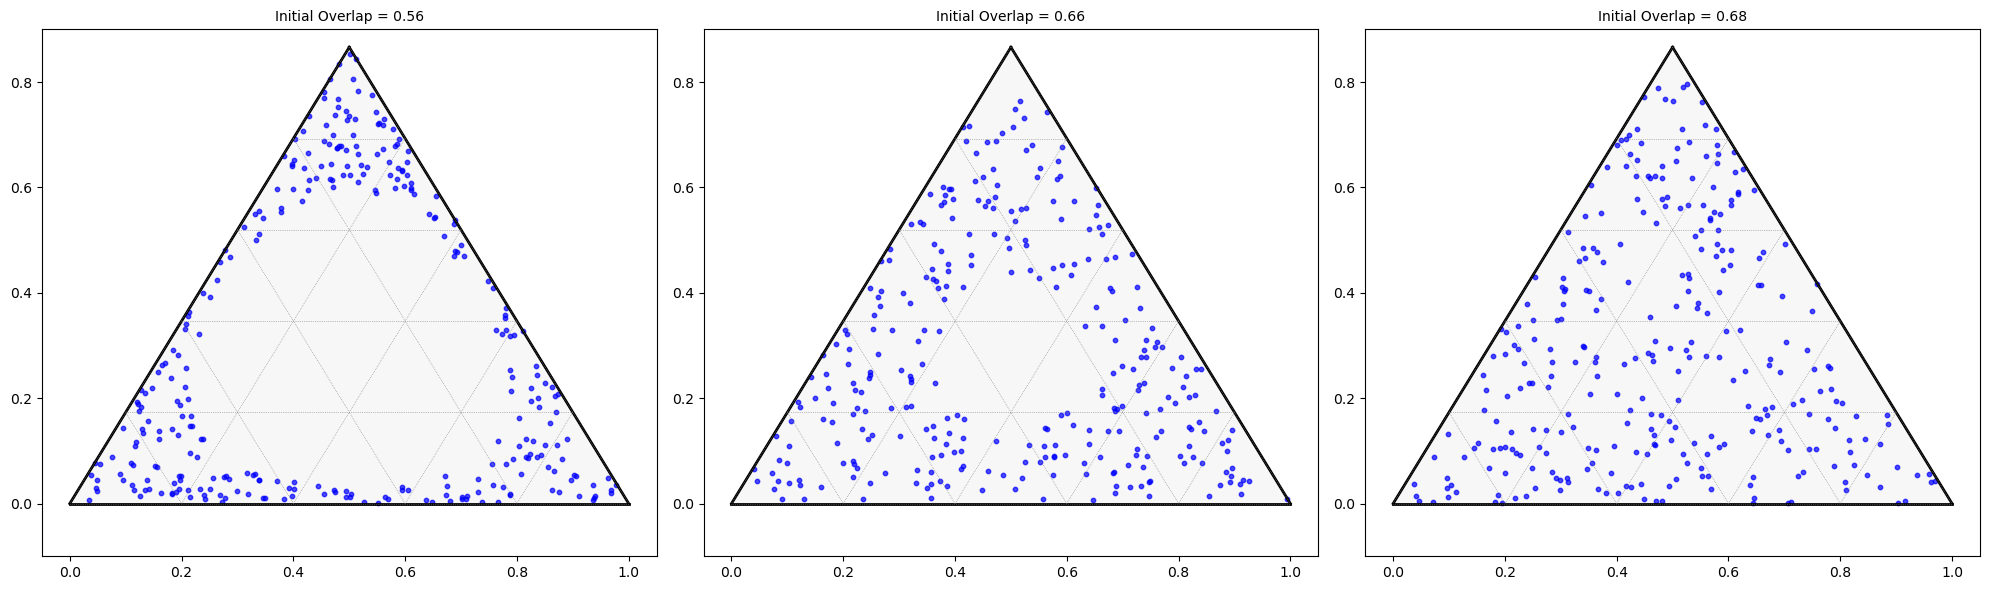

In [3]:
entropy_threshold_values = [1.2 ,1.5, 1.6]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
K = 3
N = 300
for i, entropy_threshold in enumerate(entropy_threshold_values):
    pop = generate_population(K , N, entropy_threshold)
    o = calculate_total_overlap(pop)
    print(f"Popolazione nel simplesso con Initial Overlap = {o:.2f} S_trashold = {entropy_threshold:.2f}")
    title = f'Initial Overlap = {o:.2f}'
    plot_simplesso_with_ax(pop, axes[i], title)

plt.tight_layout()
plt.savefig('GENERATE POPULATION')
plt.show()

# ORA  EVOLVIAMO LA POPOLAZIONE 

FINAL COHESION VALUE 0.5556375236297023


/Users/alicenappa/miniconda3/lib/python3.13/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


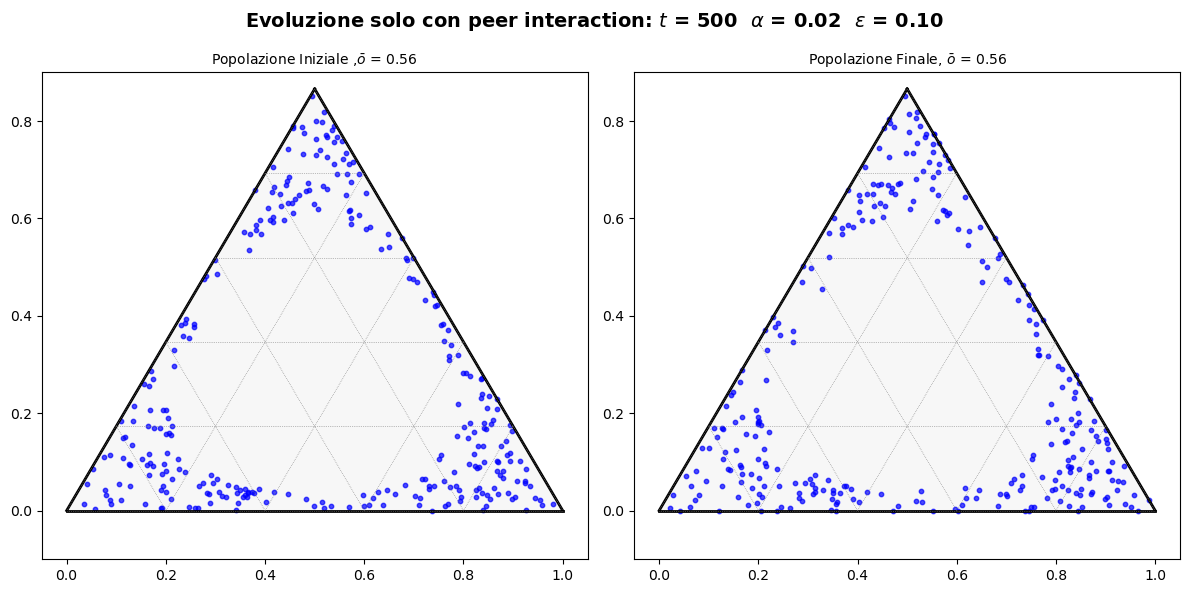

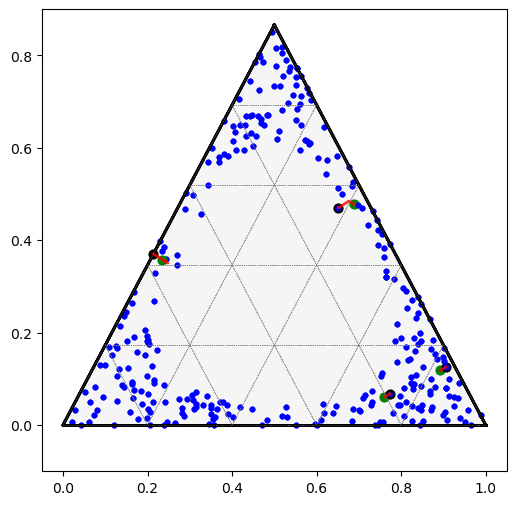

FINAL COHESION VALUE 0.5343889929325821


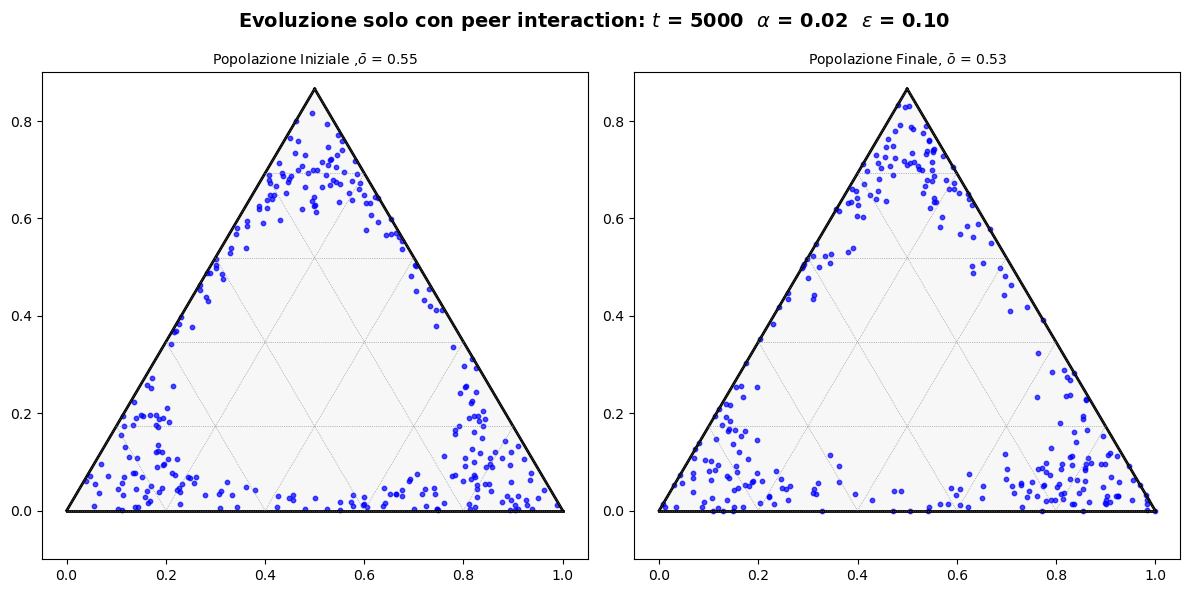

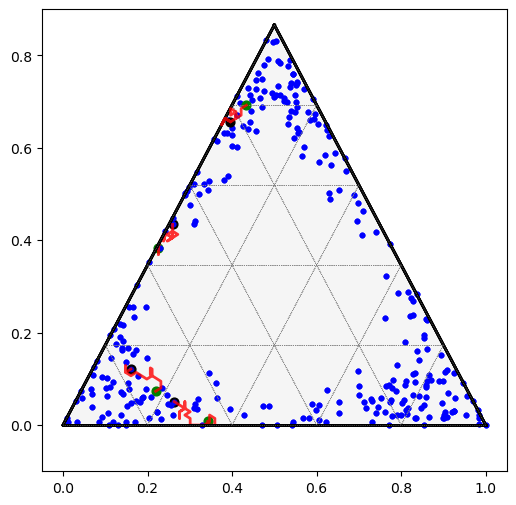

FINAL COHESION VALUE 0.35171872037057217


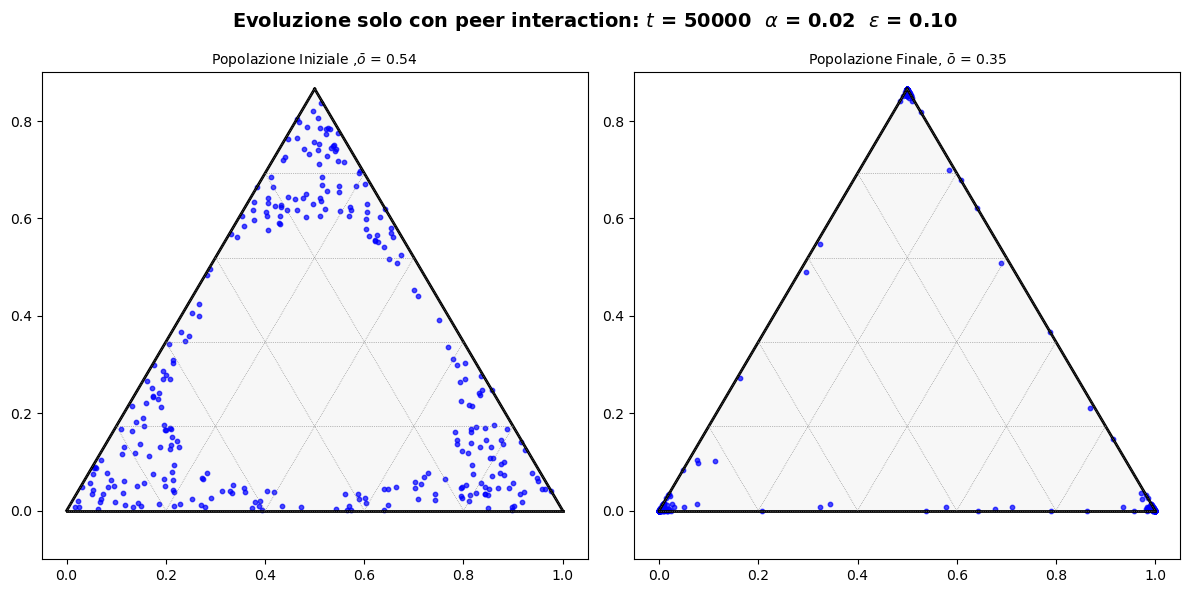

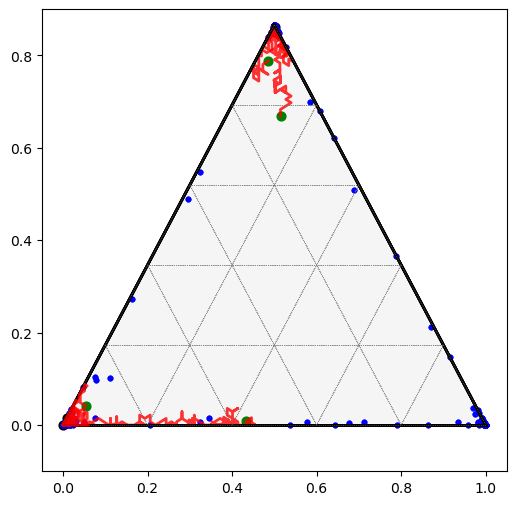

In [5]:
entropy_threshold =  1.2
alpha = 0.0167
N = 300
K=3
eps = 0.1
for time in [500, 5000, 50000]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    popolazione_iniziale = generate_population(K,N, entropy_threshold)
    o = calculate_total_overlap(popolazione_iniziale)
    plt.suptitle(rf"Evoluzione solo con peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} ", fontsize=14,  fontweight='bold')

    plot_simplesso_with_ax(popolazione_iniziale, axes[0], rf"Popolazione Iniziale ,$\bar{{o}}$ = {o:.2f}")
    pop_evoluta, storico , p , a = evolve_population_1( popolazione_iniziale , time , eps, alpha) 
    final_o =  calculate_total_overlap(pop_evoluta)
    title = f'traiettoria'

    print('FINAL COHESION VALUE' , final_o )
    plot_simplesso_with_ax(pop_evoluta, axes[1], rf"Popolazione Finale, $\bar{{o}}$ = {final_o:.2f}")
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 6))
    index_user = 3 # Cambia questo per tracciare un altro individuo
    plot_user_trajectory_from_dict(storico, index_user, ax)
    plot_user_trajectory_from_dict(storico, 10, ax)
    plot_user_trajectory_from_dict(storico, 205, ax)
    plot_user_trajectory_from_dict(storico, 50, ax)
    
    plt.show()

# PARTE DI CLUSTERING

In [7]:
high_overlap = 1.6
low_overlap = 0.95

pop_high = generate_population(3 , 100, high_overlap)
pop_low =  generate_population(3 , 100, low_overlap) 

pop_finale_high, storico , p ,a  = evolve_population_1( pop_high , 10000 , 0.1, 0.0167 )
pop_finale_low , storico , a , p  =evolve_population_1( pop_low , 10000 , 0.1, 0.0167 )


/Users/alicenappa/miniconda3/lib/python3.13/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


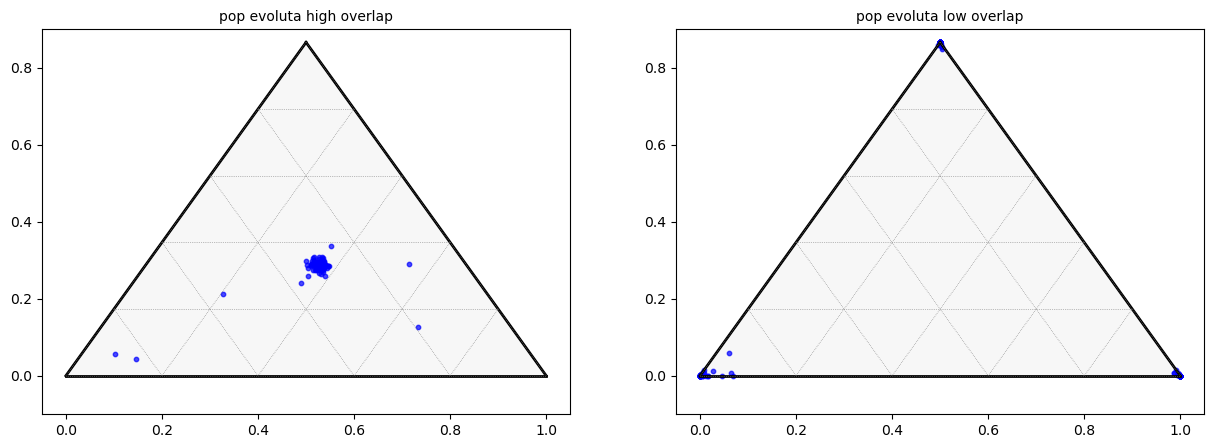

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_simplesso_with_ax(pop_finale_high,axes[0], 'pop evoluta high overlap')
plot_simplesso_with_ax(pop_finale_low ,axes[1], 'pop evoluta low overlap')

In [9]:
def hierarchical_clustering_K(population, similarity_threshold=0.8):
  
    similarity_matrix = compute_overlap_matrix(population)
    indices_over_one = np.argwhere(similarity_matrix > 1)

    # Stampa gli indici e i relativi valori
    for i, j in indices_over_one:
        similarity_matrix[i][j] = 1 
    distance_matrix = 1 - similarity_matrix
    condensed_distance = squareform(distance_matrix, checks=False)
    linkage_matrix = linkage(condensed_distance, method='complete')
    
    distance_threshold = 1 - similarity_threshold
    K = len(population[0])
    cluster_labels = fcluster(linkage_matrix, t = similarity_threshold , criterion='distance')

    return cluster_labels

In [10]:
labels_high = hierarchical_clustering_K(pop_finale_high, similarity_threshold=0.8)
labels_low  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)


pr_high = compute_PR(labels_high)
pr_low  = compute_PR(labels_low)

print("PR high:", pr_high)  # Ci si aspetta PR ≈ 1
print("PR low:", pr_low)    # Ci si aspetta PR ≈ 3 (o comunque un valore più alto)

PR high: 1.0
PR low: 2.9708853238265003


In [17]:
popolazioni = {}
Ks = [3,5,10]
eps = 0.1
alphas = [0.0167, 0.01 , 0.005 , 0.0025 , 0.00167]
times = [ 100000,300000,1000000,5000000,500000 ]
n_points = 50
entropy_ranges = {
    3: np.linspace(0.8, 1.6, n_points),
    5: np.linspace(1.6, 2.4, n_points),
    10: np.linspace(2.5, 3.7, n_points),
    20: np.linspace(3.6, 4.3, n_points),
    30: np.linspace(4.2, 5.5, n_points),
}

for i in range(3):
    print('K', Ks[i])
    alpha = alphas[i]
    K = Ks[i]
    time = times[i]
    popolazioni[K] = {}
    

    for entropy_threshold in entropy_ranges[K]:
        pop = generate_population(K, 70, entropy_threshold)
        o = calculate_total_overlap(pop)
        pop_evoluta  = evolve_population_2(pop, time, eps, alpha)
        cluster_labels = hierarchical_clustering_K(pop_evoluta, 0.8)
        pr_value = compute_PR(cluster_labels)
        popolazioni[K][o] = pr_value

K 3
K 5
K 10


In [18]:
# Check for any agents that drifted off the simplex
sums = np.sum(pop_evoluta, axis=1)
invalid_indices = np.where(~np.isclose(sums, 1.0))[0]

if len(invalid_indices) > 0:
    print(f"Error: {len(invalid_indices)} agents do not sum to 1!")
    print(f"Sample sum: {sums[invalid_indices[0]]}")

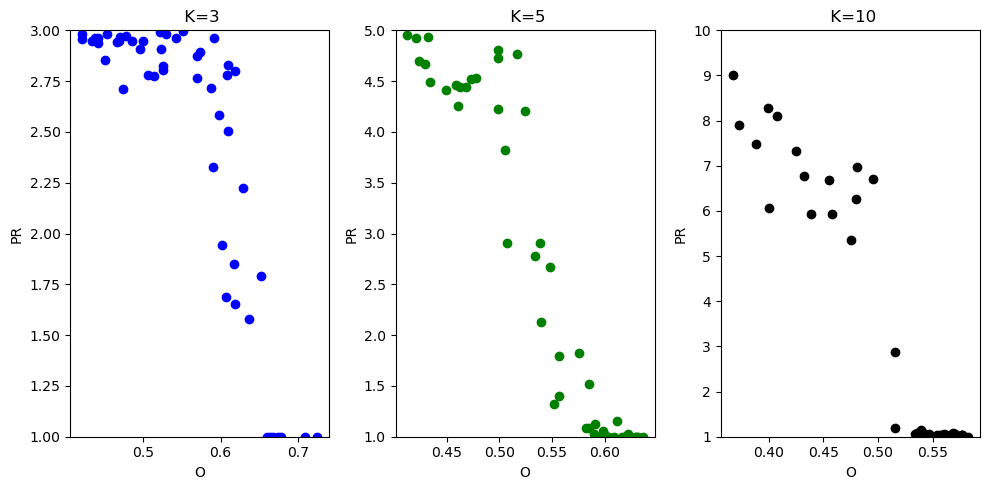

In [19]:
colors = ['blue', 'green', 'black']

fig, axs = plt.subplots(1, len(Ks), figsize=(10, 5))

for i, K in enumerate(Ks):
    ax = axs[i]
    x_values = list(popolazioni[K].keys())
    y_values = np.array(list(popolazioni[K].values()))
    
    ax.scatter(x_values, y_values, marker='o', color=colors[i], label=f"K={K}")
    ax.set_ylim(1, K)  # Imposto l'asse y da 1 a K
    ax.set_title(f" K={K}")
    ax.set_xlabel("O")
    ax.set_ylabel("PR")

plt.tight_layout()
plt.show()

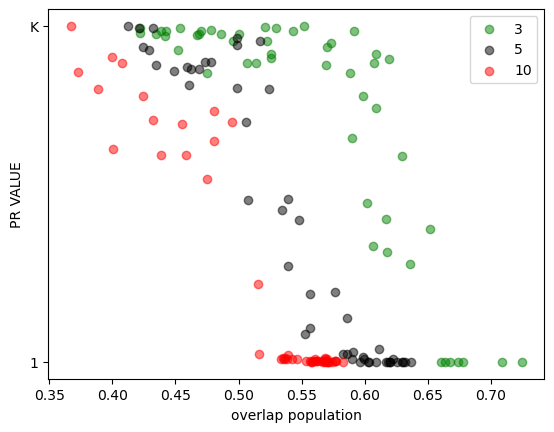

In [20]:
colors = ['green' , 'black' , 'red']
for i,K in enumerate(Ks):
    
    x_values = list(popolazioni[K].keys()) 
    y_values = np.array(list(popolazioni[K].values())) 
    x_min = y_values.min()
    x_max = y_values.max()
    data_normalized = 1 + (y_values - x_min) * (5 - 1) / (x_max - x_min)
    plt.scatter(x_values,  data_normalized ,alpha = 0.5 , color = colors[i] , label = f'{K}')
    plt.yticks([1, 5], labels=["1", "K"])

plt.xlabel('overlap population')
plt.ylabel('PR VALUE')
plt.legend()
plt.savefig('PHASE_TRANSITION_SIRBU_LORETO')

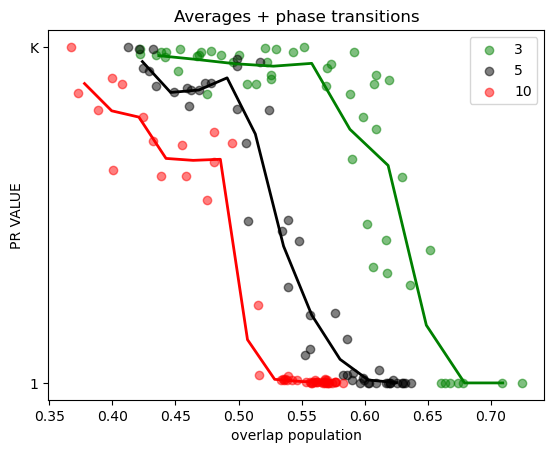

In [21]:
import numpy as np
import matplotlib.pyplot as plt

colors = ['green', 'black', 'red']
bin_count = 10
bin_averages = {}

for i, K in enumerate(Ks):
    x_values = np.array(list(popolazioni[K].keys()))
    y_values = np.array(list(popolazioni[K].values()))

   
    x_min = y_values.min()
    x_max = y_values.max()
    data_normalized = 1 + (y_values - x_min) * (5 - 1) / (x_max - x_min)

    
    plt.scatter(x_values, data_normalized, alpha=0.5, color=colors[i], label=f'{K}')

    
    bins = np.linspace(x_values.min(), x_values.max(), bin_count + 1)
    bin_indices = np.digitize(x_values, bins)

    bin_means = []
    bin_centers = []

    for j in range(1, bin_count + 1):
        bin_mask = bin_indices == j
        if np.any(bin_mask):
            mean_value = data_normalized[bin_mask].mean()
            bin_means.append(mean_value)
            bin_centers.append((bins[j - 1] + bins[j]) / 2)

    bin_averages[K] = (np.array(bin_centers), np.array(bin_means))

for i, K in enumerate(Ks):
    x_avg, y_avg = bin_averages[K]
    plt.plot(x_avg, y_avg, color=colors[i], linewidth=2)

plt.yticks([1, 5], labels=["1", "K"])
plt.xlabel('overlap population')
plt.ylabel('PR VALUE')
plt.legend()
plt.title('Averages + phase transitions')
plt.savefig('PHASE_TRANSITION_SIRBU_LORETO_averages')


# INTRODUCO EXTERNAL INFO INTERACTION

<function matplotlib.pyplot.show(close=None, block=None)>

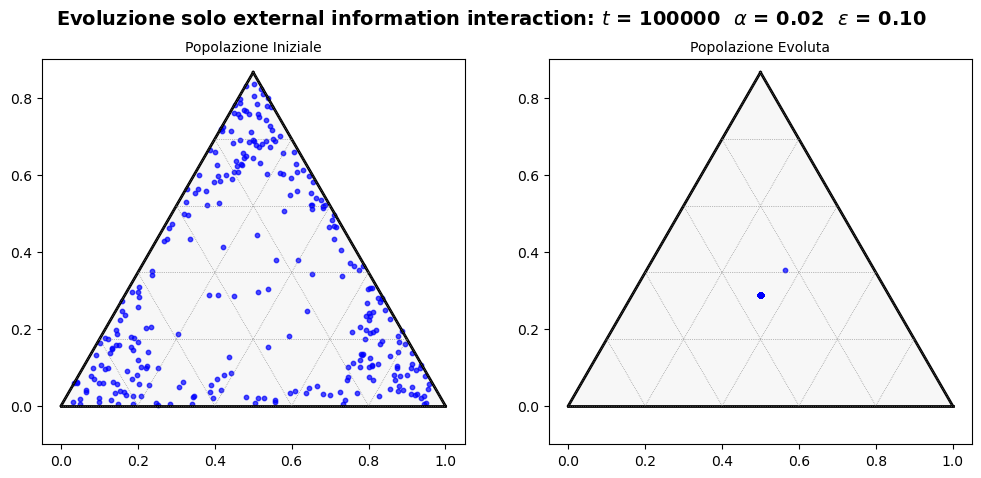

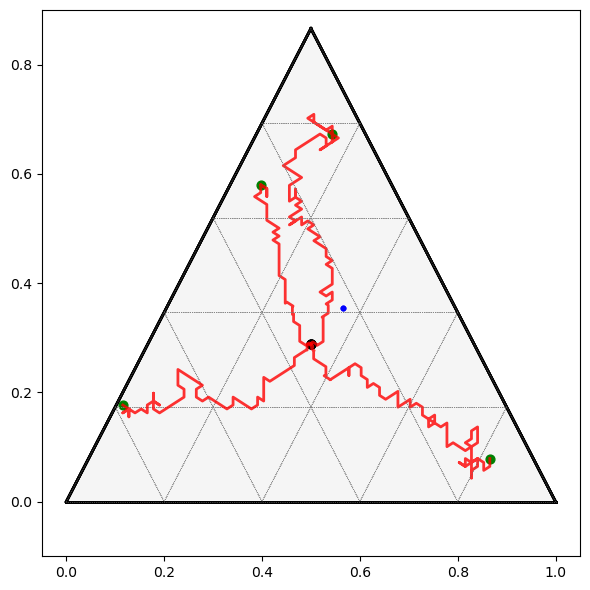

In [ ]:
PI = 0.5
a = 0.333
K  = 3
I = external_info(3,0.8)
time = 100000
pop = generate_population( K ,300, 1.2)
pop_evoluta_with_info ,storico = evolve_population_with_info( np.array(pop) , time , 0.1, 0.0167 , I , PI)    
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione solo external information interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f}", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_evoluta_with_info, axes[1], "Popolazione Evoluta")

fig, ax = plt.subplots(figsize=(6, 6))
index_user = 23 # Cambia questo per tracciare un altro individuo
plot_user_trajectory_from_dict(storico, index_user, ax)
plot_user_trajectory_from_dict(storico,131, ax)
plot_user_trajectory_from_dict(storico, 71, ax)
plot_user_trajectory_from_dict(storico, 3, ax)

plt.tight_layout()
plt.show

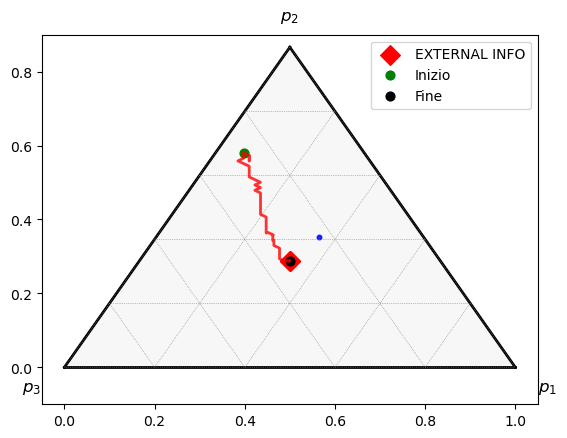

In [ ]:


# Crea la figura del plot ternario
fig, tax = ternary.figure(scale=1.0)
tax.boundary(linewidth=2.0)  # Disegna il bordo del triangolo
tax.gridlines(multiple=0.2, color="gray", linewidth=0.5)  # Aggiunge una griglia

# Esempio di dati già presenti
tax.scatter(pop_evoluta_with_info, marker="o", color="blue", s=10, alpha=0.4)

# Definisci i punti medi dei lati (midpoint) 
mid_AB = I[0]   # Lato tra i vertici (1,0,0) e (0,1,0)
mid_BC = I[1]   # Lato tra i vertici (0,1,0) e (0,0,1)
mid_CA = I[2]   # Lato tra i vertici (0,0,1) e (1,0,0)
midpoints = [mid_AB, mid_BC, mid_CA]

# Aggiungi i punti medi al plot
tax.scatter(midpoints, marker="D", color="red", s=100, label="EXTERNAL INFO")
ultimo_tempo = max(storico.keys())
tax.right_corner_label("$p_1$", fontsize=12)
tax.top_corner_label("$p_2$", fontsize=12)
tax.left_corner_label("$p_3$", fontsize=12)
tax.scatter(storico[ultimo_tempo], marker="o", color="blue", s=10, alpha=0.7)
user_trajectory = [storico[t][index_user] for t in sorted(storico.keys())]
tax.plot(user_trajectory, linewidth=2, linestyle="-", color="red", markersize=5, alpha=0.8)
tax.scatter([user_trajectory[0]], marker="o", color="green", s=40, label="Inizio")  # Punto iniziale
tax.scatter([user_trajectory[-1]], marker="o", color="black", s=40, label="Fine")  # Punto finale
tax.legend()  # Visualizza la legenda, così da identificare i punti medi
tax.show()


# INTERACT WITH RANDOM INFORMATION SOUCE 

<function matplotlib.pyplot.show(close=None, block=None)>

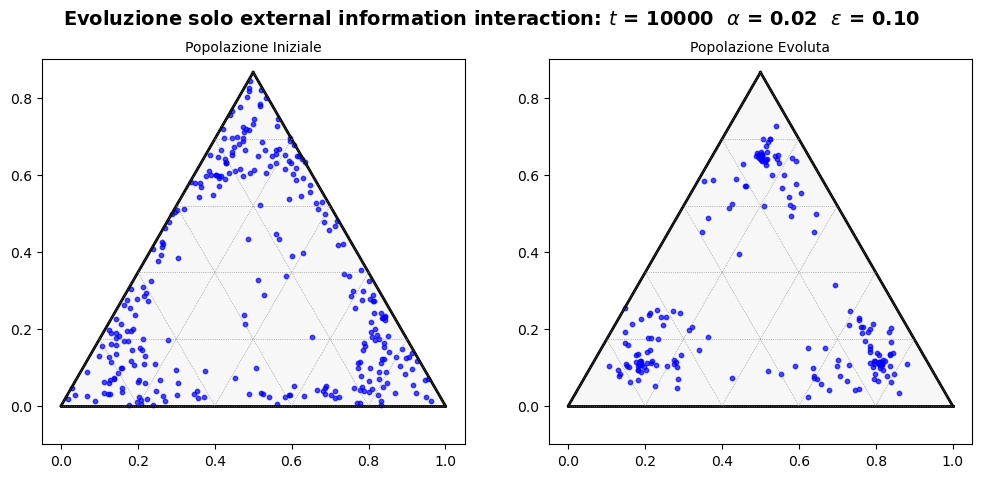

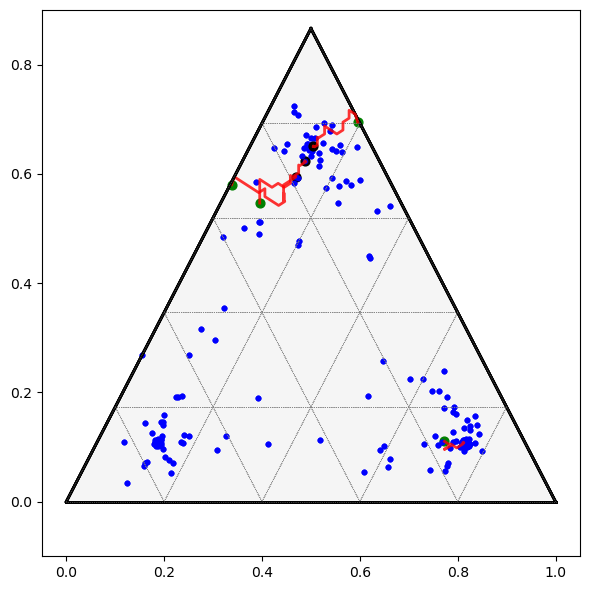

In [ ]:
PI = 0.5
a = 0.75
K  = 3
I = external_info(3,a)
time = 10000
pop = generate_population( K ,300, 1.2)
pop_evoluta_with_random_info ,storico = evolve_population_with_info( np.array(pop) , time , 0.1, 0.0167 , I , PI)    
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione solo external information interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f}", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_evoluta_with_info, axes[1], "Popolazione Evoluta")

fig, ax = plt.subplots(figsize=(6, 6))
index_user = 23 # Cambia questo per tracciare un altro individuo
plot_user_trajectory_from_dict(storico, index_user, ax)
plot_user_trajectory_from_dict(storico,131, ax)
plot_user_trajectory_from_dict(storico, 71, ax)
plot_user_trajectory_from_dict(storico, 3, ax)
plt.tight_layout()
plt.show

# EXTERNAL INFO AND PEER

<function matplotlib.pyplot.show(close=None, block=None)>

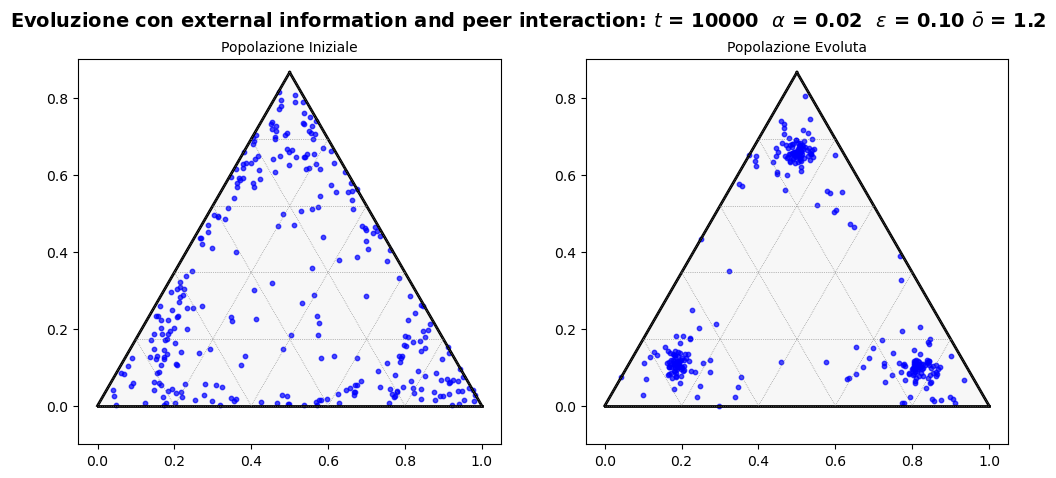

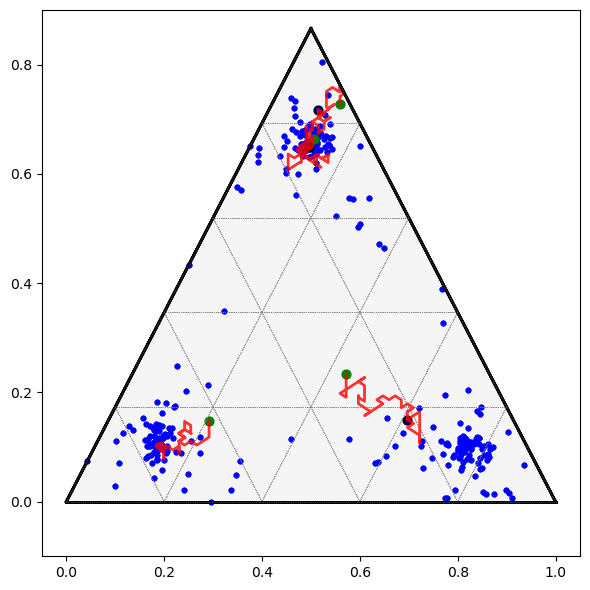

In [ ]:
PI = 0.5
a = 0.75
eps = 0.1
alpha = 0.0167
I = external_info(3,a)
time = 10000
pop = generate_population( K ,300, 1.2)
pop_evoluta_with_info_and_peer ,storico = evolve_population_with_info_and_peer( np.array(pop) , time ,eps,alpha , I , PI)    
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione con external information and peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} $\bar{{o}}$ = 1.2", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_evoluta_with_info_and_peer, axes[1], "Popolazione Evoluta")

fig, ax = plt.subplots(figsize=(6, 6))
index_user = 23 # Cambia questo per tracciare un altro individuo
plot_user_trajectory_from_dict(storico, index_user, ax)
plot_user_trajectory_from_dict(storico,131, ax)
plot_user_trajectory_from_dict(storico, 71, ax)
plot_user_trajectory_from_dict(storico, 3, ax)

plt.tight_layout()
plt.show